# How to use PlatoSim to plot sky projections

In this notebook we show how different plots of the PLATO Pointing Fields can be illustrated. 

Resources:

https://lscsoft.docs.ligo.org/ligo.skymap/plot/allsky.html#

https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_with_legend.html

https://stackoverflow.com/questions/43812911/adding-second-legend-to-scatter-plot

In [1]:
#!/usr/bin/env Python3

import os
import math
from math import sin, cos, tan, asin, atan, radians, degrees
import numpy as np
from matplotlib import pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy import units as u
from scipy import constants as c
import ligo.skymap.plot
import shapely.geometry as sg
import descartes
import platosim.referenceFrames as rf

import imp
imp.reload(rf)

plt.rcParams['text.usetex'] = True

### Constants

In [2]:
# Configuration parameters

focalLength = 247.52  # [mm]
pixelSize   = 18      # [µm]
plateScale  = 15      # [arcsec]
fovDegrees  = 18.8908
numGroups   = 4
numCorners  = 4
ccdCodes      = ["1", "2", "3", "4"]
tiltAngles    = [9.2, 9.2, 9.2, 9.2]         # [deg]
azimuthAngles = [45.0, 135.0, 225.0, 315.0]  # [deg]

# Size of the FOV

fovPixels = fovDegrees / plateScale * c.degree / c.arcsec
fovMm     = focalLength * np.tan(np.deg2rad(fovDegrees))

### Functions

In [6]:
def mm2pixels(distanceMm):
    """
    Conversion from millimeters to pixels.
    :param distanceMm: Distance [mm].
    :return distancePixels: Distance [pixels].
    """
    distancePixels = degrees(atan(distanceMm / focalLength)) / plateScale * c.degree / c.arcsec
    return distancePixels




def coorCameraGroup(raPlatform, decPlatform):
    # Function to find the pointing of each Camera group
    
    # Find coordinates of the Sun [rad]
    raSun, decSun = rf.sunSkyCoordinatesAwayfromPlatformPointing(np.deg2rad(raPlatform), 
                                                                 np.deg2rad(decPlatform), 
                                                                 0.)

    sign = lambda x: (1, -1)[x < 0]
    raTelescope = []
    decTelescope = []

    for group in range(0, numGroups):
    
        # Telescope pointing (absolute) [rad]
        ra, dec = rf.platformToTelescopePointingCoordinates(np.deg2rad(raPlatform), 
                                                            np.deg2rad(decPlatform), 
                                                            raSun, decSun, 
                                                            np.deg2rad(azimuthAngles[group]), 
                                                            np.deg2rad(tiltAngles[group]))
        # Telescope pointing [deg]
        raTelescope.append(np.rad2deg(ra))
        decTelescope.append(np.rad2deg(dec))

    # Convert to SkyCoord object and return
    return SkyCoord(raTelescope*u.deg, decTelescope*u.deg, frame='icrs', unit='deg')     

## Camera & CCD FOV

In [8]:
xPixels = np.copy(xFP)
yPixels = np.copy(yFP)

for group in range(numGroups):
    
    xPixels[group] = mm2pixels(xPixels[group])     # [mm] -> [pixels]
    yPixels[group] = mm2pixels(yPixels[group])     # [mm] -> [pixels]

NameError: name 'xFP' is not defined

In [7]:
index = 0
refCcdCode = "1"

cornersX, cornersY = rf.computeCCDcornersInFocalPlane(refCcdCode, pixelSize)
offsetX = mm2pixels(cornersX[index]) + xPixels[refGroup - 1]
offsetY = mm2pixels(cornersY[index]) + yPixels[refGroup - 1]

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111)

circles = []
for group in range(numGroups):
    circles.append(sg.Point(-(xPixels[group] - offsetX), 
                            -(yPixels[group] - offsetY)).buffer(fovPixels))

for index in range(numCorners):
    
    one = circles[index].intersection(circles[index])
    ax.add_patch(descartes.PolygonPatch(one, fc='gray', ec='none', alpha=0.2))
    
    two = circles[index].intersection(circles[(index + 1) % numCorners])
    ax.add_patch(descartes.PolygonPatch(two, fc='gray', ec='none', alpha=0.2))
    
    three = circles[index].intersection(circles[(index + 1) % numCorners]).intersection(circles[(index + 2) % numCorners])
    ax.add_patch(descartes.PolygonPatch(three, fc='gray', ec='none', alpha=0.2))
    
four = circles[0].intersection(circles[1]).intersection(circles[2]).intersection(circles[3])
ax.add_patch(descartes.PolygonPatch(four, fc='gray', ec='none', alpha=0.2))

for ccdCode in ccdCodes:
    
    cornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)
    
    for corner in range(numCorners):
        cornersX[corner] = mm2pixels(cornersX[corner])
        cornersY[corner] = mm2pixels(cornersY[corner])
    
    cornersX = np.append(cornersX, cornersX[0])     # [mm]
    cornersY = np.append(cornersY, cornersY[0])     # [mm]
    
    for group in range(numGroups):
        
        arrayX = cornersX + xPixels[group] - offsetX
        arrayY = cornersY + yPixels[group] - offsetY
        
        for index in range(5):
            arrayX[index] = (arrayX[index])
            arrayY[index] = (arrayY[index])
        
        plt.plot(-arrayX, -arrayY, color=colors[group])
        
        off = 4000
        ax.text(-(xPixels[group] - offsetX + sign(cornersX[3]) * off), 
                -(yPixels[group] - offsetY + sign(cornersY[3]) * off), 
                ccdCode, fontsize = 24, color=colors[group])
        
for group in range(numGroups):
    
    plt.plot([-(xPixels[group] - offsetX)], 
             [-(yPixels[group] - offsetY)], 
             color=colors[group], marker="o")
    
    circ = plt.Circle(((-(xPixels[group] - offsetX)), 
                       (-(yPixels[group] - offsetY))), 
                      radius = fovPixels, color = "none", 
                      linewidth = 2, label="Group " + str(group + 1))
    ax.add_patch(circ)
    circ.set_edgecolor(colors[group])
    circ.set_facecolor("none")

plt.plot([0], [0], "kx", mew=5, ms=10, label="CCD origin")
            
plt.legend(prop={"size": 20}, bbox_to_anchor=(1.0, 1.0))
title = "CCD " + refCcdCode + " in group " + str(refGroup)
ax.set_title(title, fontsize = 28)
ax.set_xlabel("column [pixels]", fontsize = 24)
ax.set_ylabel("row [pixel]", fontsize = 24)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)

from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)

ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=7)
ax.tick_params(which='minor', length=4, color='r')
ax.grid(True)
ax.set_xticks(np.arange(-5000, 9000, 1000))
ax.set_yticks(np.arange(0, 13000, 1000))
ax.arrow(0, 0, 7750, 0, head_width=200, head_length=200, fc='k', ec='k', linewidth=4)
ax.arrow(0, 0, 0, 12250, head_width=200, head_length=200, fc='k', ec='k', linewidth=4)

plt.show()

NameError: name 'xPixels' is not defined

## Load data

In [4]:
# Introduce pointing fields

SPF_gal = [253.0, -30.0]
NPF_gal = [65.0, 30.0]

SPF_gal = SkyCoord(SPF_gal[0], SPF_gal[1], frame='galactic', unit='deg')  # [deg]
NPF_gal = SkyCoord(NPF_gal[0], NPF_gal[1], frame='galactic', unit='deg')  # [deg]

SPF_icrs = SPF_gal.icrs  # [deg]
NPF_icrs = NPF_gal.icrs  # [deg]

# Load stars
inputDir = os.getenv('PLATO_WORKDIR') + '/platonium/pic/PIC1.1.0'

# Load NPF stars

NPF06 = np.load(inputDir + '/NPF-NCAM06.npy')
NPF12 = np.load(inputDir + '/NPF-NCAM12.npy')
NPF18 = np.load(inputDir + '/NPF-NCAM18.npy')
NPF24 = np.load(inputDir + '/NPF-NCAM24.npy')

starNPF06 = SkyCoord(NPF06[:,0]*u.deg, NPF06[:,1]*u.deg, frame='icrs', unit='deg')
starNPF12 = SkyCoord(NPF12[:,0]*u.deg, NPF12[:,1]*u.deg, frame='icrs', unit='deg')
starNPF18 = SkyCoord(NPF18[:,0]*u.deg, NPF18[:,1]*u.deg, frame='icrs', unit='deg')
starNPF24 = SkyCoord(NPF24[:,0]*u.deg, NPF24[:,1]*u.deg, frame='icrs', unit='deg')

# Load SPF stars

SPF06 = np.load(inputDir + '/SPF-NCAM06.npy')
SPF12 = np.load(inputDir + '/SPF-NCAM12.npy')
SPF18 = np.load(inputDir + '/SPF-NCAM18.npy')
SPF24 = np.load(inputDir + '/SPF-NCAM24.npy')

starSPF06 = SkyCoord(SPF06[:,0]*u.deg, SPF06[:,1]*u.deg, frame='icrs', unit='deg')
starSPF12 = SkyCoord(SPF12[:,0]*u.deg, SPF12[:,1]*u.deg, frame='icrs', unit='deg')
starSPF18 = SkyCoord(SPF18[:,0]*u.deg, SPF18[:,1]*u.deg, frame='icrs', unit='deg')
starSPF24 = SkyCoord(SPF24[:,0]*u.deg, SPF24[:,1]*u.deg, frame='icrs', unit='deg')

In [5]:
sign = lambda x: (1, -1)[x < 0]

In [6]:
# Arbitrary choice of platform pointing and solar-panel orientation

raPlatform = 10.               # [degrees]
decPlatform = 10.              # [degrees]
solarPanelOrientation = 0.     # [degrees]

raSun, decSun = rf.sunSkyCoordinatesAwayfromPlatformPointing(radians(raPlatform), radians(decPlatform), solarPanelOrientation)



raTelescope = []
decTelescope = []

for group in range(0, numGroups):
    
    # Telescope pointing (absolute)
    
    ra, dec = rf.platformToTelescopePointingCoordinates(radians(raPlatform), radians(decPlatform), raSun, decSun, radians(azimuthAngles[group]), radians(tiltAngles[group]))     # [radians]
    
    # Telescope pointing w.r.t. platform pointing
    
    raTelescope.append(degrees(ra) - raPlatform)     # [degrees]
    decTelescope.append(degrees(dec) - decPlatform)  # [degrees]
    
meanDist = (np.mean(np.absolute(raTelescope)) + np.mean(np.absolute(decTelescope))) / 2.0

for group in range(numGroups):
    
    raTelescope[group] = sign(raTelescope[group]) * meanDist
    decTelescope[group] = sign(decTelescope[group]) * meanDist



/lhome/nicholas/.local/lib/python3.8/site-packages/descartes/patch.py:63: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  concatenate([asarray(t.exterior)[:, :2]] +


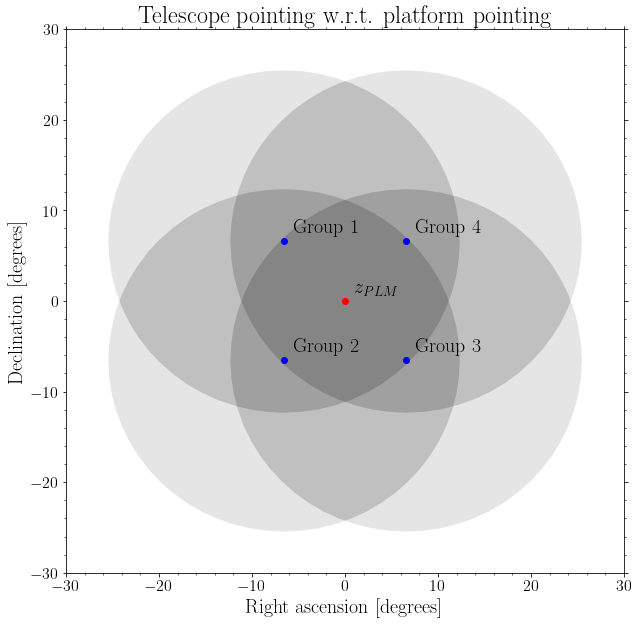

In [7]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

ax.plot([raPlatform - raPlatform], [decPlatform - decPlatform], "ro")
ax.plot(raTelescope, decTelescope, "bo")

offset = 1

for group in range(numGroups):
    
    ax.text(raTelescope[group] + offset, decTelescope[group] + offset, "Group " + str(group + 1), fontsize = 20)

ax.text(0 + offset, 0 + offset, "$z_{PLM}$", fontsize = 20)
    
circles = []
for group in range(numGroups):
    circles.append(sg.Point(raTelescope[group], decTelescope[group]).buffer(fovDegrees))

for index in range(numGroups):
    
    one = circles[index].intersection(circles[index])
    ax.add_patch(descartes.PolygonPatch(one, fc='gray', ec='none', alpha=0.2))
    
    two = circles[index].intersection(circles[(index + 1) % numCorners])
    ax.add_patch(descartes.PolygonPatch(two, fc='gray', ec='none', alpha=0.2))
    
    three = circles[index].intersection(circles[(index + 1) % numCorners]).intersection(circles[(index + 2) % numCorners])
    ax.add_patch(descartes.PolygonPatch(three, fc='gray', ec='none', alpha=0.2))
    
four = circles[0].intersection(circles[1]).intersection(circles[2]).intersection(circles[3])
ax.add_patch(descartes.PolygonPatch(four, fc='gray', ec='none', alpha=0.2))
    
ax.set_title('Telescope pointing w.r.t. platform pointing', fontsize = 24)
ax.set_xlabel('Right ascension [degrees]', fontsize = 20)
ax.set_ylabel('Declination [degrees]', fontsize = 20)
plt.xlim([-30, 30])
plt.ylim([-30, 30])
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

## Plot camera groups in focal plane

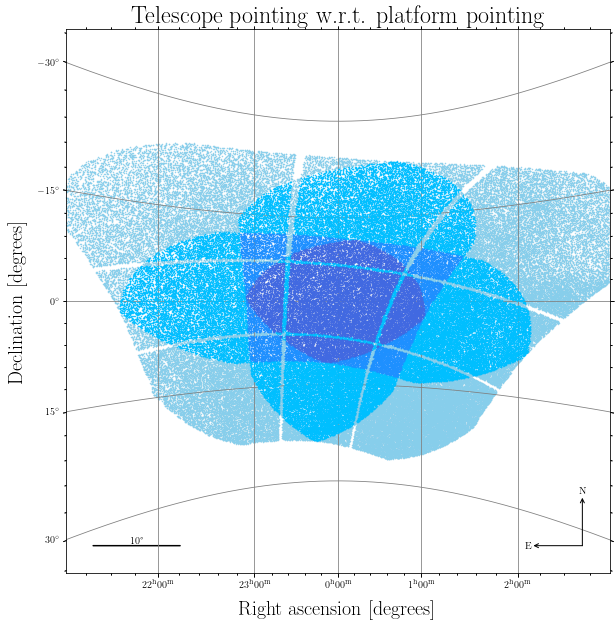

In [21]:
# Calculate camera pointings

raPlatform   = SPF_icrs.ra.deg
decPlatform  = SPF_icrs.dec.deg

camPointing  = coorCameraGroup(raPlatform, decPlatform)
raTelescope  = camPointing.ra.deg  - NPF_icrs.ra.deg 
decTelescope = camPointing.dec.deg - NPF_icrs.dec.deg


pointing = SkyCoord(0*u.deg, 0*u.deg, frame='icrs', unit='deg')

color  = 'skyblue'
offset = 1

# Start plot 

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='astro zoom', center=pointing, radius='50 deg', rotate='0 deg')
#ax = fig.add_subplot(111)

ax.plot(starSPF06.ra.deg-SPF_icrs.ra.deg, starSPF06.dec.deg-SPF_icrs.dec.deg, '.', c='skyblue',     transform=ax.get_transform('world'), markersize=1, zorder=1)
ax.plot(starSPF12.ra.deg-SPF_icrs.ra.deg, starSPF12.dec.deg-SPF_icrs.dec.deg, '.', c='deepskyblue', transform=ax.get_transform('world'), markersize=1, zorder=2)
ax.plot(starSPF18.ra.deg-SPF_icrs.ra.deg, starSPF18.dec.deg-SPF_icrs.dec.deg, '.', c='dodgerblue',  transform=ax.get_transform('world'), markersize=1, zorder=3)
ax.plot(starSPF24.ra.deg-SPF_icrs.ra.deg, starSPF24.dec.deg-SPF_icrs.dec.deg, '.', c='royalblue',   transform=ax.get_transform('world'), markersize=1, zorder=4)

# Plot platform ponting

# ax.plot(raPlatform,  decPlatform,  "r*", transform=ax.get_transform('world'), markersize=10, zorder=5)
# ax.plot(raTelescope, decTelescope, "r+", transform=ax.get_transform('world'), markersize=10, zorder=5)


offset = 1

# for group in range(numGroups):    
#     ax.text(raTelescope[group] + offset, decTelescope[group] + offset, "Group " + str(group + 1), fontsize = 20)

# ax.text(raPlatform+offset, decPlatform+offset, "$z_{PLM}$", fontsize=20, transform=ax.get_transform('world'), zorder=6)




# d circles
# circles = []
# for group in range(numGroups):
#     circles.append(sg.Point(raTelescope[group], decTelescope[group]).buffer(fovDegrees))

# for index in range(numGroups):
    
#     one = circles[index].intersection(circles[index])
#     ax.add_patch(descartes.PolygonPatch(one, fc=color, ec='b', alpha=1, transform=ax.get_transform('world'), zorder=7))
    
#     two = circles[index].intersection(circles[(index + 1) % numCorners])
#     ax.add_patch(descartes.PolygonPatch(two, fc=color, ec='b', alpha=0.1))
    
#     three = circles[index].intersection(circles[(index + 1) % numCorners]).intersection(circles[(index + 2) % numCorners])
#     ax.add_patch(descartes.PolygonPatch(three, fc=color, ec='b', alpha=0.1))
    
# four = circles[0].intersection(circles[1]).intersection(circles[2]).intersection(circles[3])
# ax.add_patch(descartes.PolygonPatch(four, fc=color, ec='b', alpha=0.1))

# Add-on's                                                                                                                                                                                                                                                                            
ax.scalebar((0.05, 0.05), 10 * u.deg).label()                                                                                                                                                                                                                                         
ax.compass(0.95, 0.05, 0.1)                                                                                                                                                                                                                                                           
ax.grid(color='gray')

ax.set_title('Telescope pointing w.r.t. platform pointing', fontsize = 24)
ax.set_xlabel('Right ascension [degrees]', fontsize = 20)
ax.set_ylabel('Declination [degrees]', fontsize = 20)
#plt.xlim([raPlatform-30, raPlatform+30])
#plt.ylim([decPlatform-30, decPlatform+30])
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

## Plot PLATO FOVs

In [ ]:
# Load brightest stars

NPFsat = np.loadtxt(os.getcwd() + '/NPF-less5mag-Targets.txt')
SPFsat = np.loadtxt(os.getcwd() + '/SPF-less5mag-Targets.txt')

starNPFsat = SkyCoord(NPFsat[:,0]*u.deg, NPFsat[:,1]*u.deg, frame='icrs', unit='deg')
starSPFsat = SkyCoord(SPFsat[:,0]*u.deg, SPFsat[:,1]*u.deg, frame='icrs', unit='deg')

In [ ]:
# PLOT OF NPF PIC STARS

camPointing = coorCameraGroup(NPF_icrs.ra.deg, NPF_icrs.dec.deg)

# Start plot

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='astro zoom', center=NPF_icrs, radius='35 deg', rotate='180 deg')

# Plot PIC1.1.0 stars after N-CAM visibility

ax.plot(starNPF06.ra.deg, starNPF06.dec.deg, '.', c='skyblue', transform=ax.get_transform('world'), markersize=1, zorder=1)
ax.plot(starNPF12.ra.deg, starNPF12.dec.deg, '.', c='deepskyblue', transform=ax.get_transform('world'), markersize=1, zorder=2)
ax.plot(starNPF18.ra.deg, starNPF18.dec.deg, '.', c='dodgerblue', transform=ax.get_transform('world'), markersize=1, zorder=3)
ax.plot(starNPF24.ra.deg, starNPF24.dec.deg, '.', c='royalblue', transform=ax.get_transform('world'), markersize=1, zorder=4)

# Plot saturated stars and add legend scaled to the stellar magnitudes

s = np.arange(2,6) * 3.5
sNPF = ( (np.max(NPFsat[:,2]) - NPFsat[:,2]) + 0.5) * 100
scatter = ax.scatter(starNPFsat.ra.deg, starNPFsat.dec.deg, transform=ax.get_transform('world'), 
                     s=sNPF, marker='o', c='gold', ec='k', lw=1, zorder=5)
handle = [plt.plot([],[], "o", c='gray', ms=s[i], ls="")[0] for i in range(len(s))]
ax.legend(handles=handle, labels=[5,4,3,2],loc='upper right', title=r"$P$ [mag]", fontsize=14, title_fontsize=16)

# Plot pointing of each camera group

#ax.plot(camPointing.ra.deg, camPointing.dec.deg, 'rx', transform=ax.get_transform('world'), markersize=10, zorder=6)


# Plot pointing of PIC1.1.0 and PIC2.0.0

ax.plot(NPF_icrs.ra.deg, NPF_icrs.dec.deg, '*', transform=ax.get_transform('world'), ms=20, c='k', mfc='r', zorder=6)
ax.plot(277.18, 52.85, '*', transform=ax.get_transform('world'), ms=20, c='k', mfc='b', zorder=7)
       
# Add-on's

ax.scalebar((0.05, 0.05), 10 * u.deg).label()
ax.compass(0.95, 0.05, 0.1)
ax.grid(color='gray')

# Settings

ax.set_title('NPF pointing', fontsize = 24)
ax.set_xlabel('RA', fontsize = 20)
ax.set_ylabel('Dec', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
ax.tick_params(axis='both', labelsize=16)

# Plot and save

plt.show()
fig.savefig(os.getcwd()+'/plot_NPF_pointing.png', bbox_inches='tight', dpi=300)

In [ ]:
# Select pointing

camPointing = coorCameraGroup(SPF_icrs.ra.deg, SPF_icrs.dec.deg)

# Start plot

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='astro zoom', center=SPF_icrs, radius='35 deg', rotate='180 deg')

# Plot PIC1.1.0 stars after N-CAM visibility

ax.plot(starSPF06.ra.deg, starSPF06.dec.deg, '.', c='skyblue', transform=ax.get_transform('world'), markersize=1)
ax.plot(starSPF12.ra.deg, starSPF12.dec.deg, '.', c='deepskyblue', transform=ax.get_transform('world'), markersize=1)
ax.plot(starSPF18.ra.deg, starSPF18.dec.deg, '.', c='dodgerblue', transform=ax.get_transform('world'), markersize=1)
ax.plot(starSPF24.ra.deg, starSPF24.dec.deg, '.', c='royalblue', transform=ax.get_transform('world'), markersize=1)

# Plot bright stars and add legend after magnitude

s = np.arange(2,6) * 3.5
magSPF = ( (np.max(SPFsat[:,2]) - SPFsat[:,2]) + 0.5) * 100
ax.scatter(starSPFsat.ra.deg, starSPFsat.dec.deg, transform=ax.get_transform('world'), s=magSPF, marker='o', c='gold', ec='k', lw=1, zorder=5)
handle = [plt.plot([],[], "o", c='gray', ms=s[i], ls="")[0] for i in range(len(s))]
ax.legend(handles=handle, labels=[5,4,3,2],loc='upper right', title=r"$P$ [mag]", fontsize=14, title_fontsize=16)

# Plot pointing of each camera group

#ax.plot(camPointing.ra.deg, camPointing.dec.deg, 'rx', transform=ax.get_transform('world'), ms=15, )

# Plot pointing of PIC1.1.0 and PIC2.0.0

ax.plot(SPF_icrs.ra.deg, SPF_icrs.dec.deg, '*', transform=ax.get_transform('world'), ms=20, c='k', mfc='r')
ax.plot(93.49134, -42.93544, '*', transform=ax.get_transform('world'), ms=20, c='k', mfc='b')
    
# Add-on's

ax.scalebar((0.05, 0.05), 10 * u.deg).label()
ax.compass(0.95, 0.05, 0.1)
ax.grid(color='gray')

# Labels

ax.set_title('SPF pointing', fontsize = 24)
ax.set_xlabel('RA (J2000)', fontsize = 20)
ax.set_ylabel('Dec (J2000)', fontsize = 20)
ax.tick_params(axis='both', labelsize=16)

# Plot and save image
plt.show()
fig.savefig(os.getcwd()+'/plot_SPF_pointing.png', bbox_inches='tight', dpi=300)